# Overview

In this notebook, we will go through the task generation pipeline in LIBERO. We will cover the following contents:

1. Retrieve a list of available objects, predicates
 in the codebase
2. Define your own initial state distribution
3. Define your own task goal
4. Generate the pddl file for the task

Now, let's get started!

## 1. Retrieve a list of objects available

In order for the sucess in task generation, we need to make sure that the objects and the predicates (object relations) specified are available in the codebase.

In [2]:
from libero.libero.envs.objects import get_object_dict, get_object_fn

# Get a dictionary of all the objects
object_dict = get_object_dict()
print(object_dict)

[robosuite WARNING] No private macro file found! (__init__.py:7)
[robosuite WARNING] It is recommended to use a private macro file (__init__.py:8)
[robosuite WARNING] To setup, run: python /Users/cindy/miniconda3/envs/libero/lib/python3.8/site-packages/robosuite/scripts/setup_macros.py (__init__.py:9)


{'alphabet_soup': <class 'libero.libero.envs.objects.hope_objects.AlphabetSoup'>, 'bbq_sauce': <class 'libero.libero.envs.objects.hope_objects.BbqSauce'>, 'butter': <class 'libero.libero.envs.objects.hope_objects.Butter'>, 'cherries': <class 'libero.libero.envs.objects.hope_objects.Cherries'>, 'chocolate_pudding': <class 'libero.libero.envs.objects.hope_objects.ChocolatePudding'>, 'cookies': <class 'libero.libero.envs.objects.hope_objects.Cookies'>, 'corn': <class 'libero.libero.envs.objects.hope_objects.Corn'>, 'cream_cheese': <class 'libero.libero.envs.objects.hope_objects.CreamCheese'>, 'ketchup': <class 'libero.libero.envs.objects.hope_objects.Ketchup'>, 'macaroni_and_cheese': <class 'libero.libero.envs.objects.hope_objects.MacaroniAndCheese'>, 'mayo': <class 'libero.libero.envs.objects.hope_objects.Mayo'>, 'milk': <class 'libero.libero.envs.objects.hope_objects.Milk'>, 'orange_juice': <class 'libero.libero.envs.objects.hope_objects.OrangeJuice'>, 'popcorn': <class 'libero.libero.e

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


Now you can see all the available objects, you can retrieve the object class by specifying their categories (which are the keys in the dictionary)

In [7]:
category_name = "conveyor_belt"
object_cls = get_object_fn(category_name)
print(category_name, ": defined in the class ", object_cls)

conveyor_belt : defined in the class  <class 'libero.libero.envs.objects.industry_objects.ConveyorBelt'>


Similarly, you can retrieve the information about predicates.

In [8]:
from libero.libero.envs.predicates import get_predicate_fn_dict, get_predicate_fn

predicate_dict = get_predicate_fn_dict()
print(predicate_dict)
print("=============")
predicate_name = "on"
print(get_predicate_fn(predicate_name))


{'true': <libero.libero.envs.predicates.base_predicates.TruePredicateFn object at 0x7fbf98dd2b80>, 'false': <libero.libero.envs.predicates.base_predicates.FalsePredicateFn object at 0x7fbf98dd2bb0>, 'in': <libero.libero.envs.predicates.base_predicates.In object at 0x7fbf98dd2be0>, 'on': <libero.libero.envs.predicates.base_predicates.On object at 0x7fbf98dd2c40>, 'up': <libero.libero.envs.predicates.base_predicates.Up object at 0x7fbf98dd2c10>, 'printjointstate': <libero.libero.envs.predicates.base_predicates.PrintJointState object at 0x7fbf98dd2ee0>, 'open': <libero.libero.envs.predicates.base_predicates.Open object at 0x7fbf98dd2fd0>, 'close': <libero.libero.envs.predicates.base_predicates.Close object at 0x7fbf98ddf100>, 'turnon': <libero.libero.envs.predicates.base_predicates.TurnOn object at 0x7fbf98ddf1f0>, 'turnoff': <libero.libero.envs.predicates.base_predicates.TurnOff object at 0x7fbf98ddf310>}


## 2. Define your own initial state distribution

In [4]:
import numpy as np
from libero.libero.utils.bddl_generation_utils import get_xy_region_kwargs_list_from_regions_info
from libero.libero.utils.mu_utils import register_mu, InitialSceneTemplates, MU_DICT
from libero.libero.utils.task_generation_utils import register_task_info, get_task_info, generate_bddl_from_task_info


@register_mu(scene_type="floor_manipulation")
class FloorManipulation(InitialSceneTemplates):
    def __init__(self):
        # 1. 配置夹具（fixture）数量：仅floor，数量1
        fixture_num_info = {
            "floor": 1,
        }

        # 2. 配置物体（object）数量：对应BDDL中的所有物体，数量均为1
        object_num_info = {
#            "alphabet_soup": 3,   
            "basket": 1,          
            "salad_dressing": 3,   
            "cream_cheese": 1,   
            "milk": 2,            
#            "tomato_sauce": 1,    
#            "butter": 1,           
        }

        # 初始化场景：核心工作空间为floor（所有物体都在floor上）
        super().__init__(
            workspace_name="floor",          # 对应BDDL中的:target floor
            fixture_num_info=fixture_num_info,
            object_num_info=object_num_info
        )


    def define_regions(self):
        # 3. 定义所有区域（对应BDDL中的:regions部分）
        # 3.1 bin_region（basket_1的放置区域）：添加yaw_rotation参数
        self.regions.update(
            self.get_region_dict(
                region_centroid_xy=[0.0, 0.26],    # 中心坐标 (x, y)
                region_name="bin_region",          # 区域名称
                target_name=self.workspace_name,   # 目标工作空间（floor）
                region_half_len=0.01,              # 区域半长
                yaw_rotation=(np.pi, np.pi)        # 偏航旋转：固定π弧度（180度）
            )
        )

        # 3.2 target_object_region（cream_cheese_1）：自定义旋转范围（0到2π，即360度随机）
        self.regions.update(
            self.get_region_dict(
                region_centroid_xy=[-0.12, -0.24],
                region_name="target_object_region",
                target_name=self.workspace_name,
                region_half_len=0.025,
                yaw_rotation=(0, 2 * np.pi)        # 随机偏航角（0~360度）
            )
        )

        # 3.3 other_object_region_0（cream_cheese_2）：固定0弧度（0度）
        self.regions.update(
            self.get_region_dict(
                region_centroid_xy=[0.05, -0.10],
                region_name="other_object_region_0",
                target_name=self.workspace_name,
                region_half_len=0.025,
                yaw_rotation=(0, 0)                # 无旋转
            )
        )

        # 3.4 other_object_region_1（cream_cheese_3）：自定义范围（-π/2 到 π/2，即-90~90度）
        self.regions.update(
            self.get_region_dict(
                region_centroid_xy=[-0.15, 0.06],
                region_name="other_object_region_1",
                target_name=self.workspace_name,
                region_half_len=0.025,
                yaw_rotation=(-np.pi/2, np.pi/2)   # 偏航角范围：-90° ~ 90°
            )
        )

        # 3.5 other_object_region_2（cream_cheese_4）
        self.regions.update(
            self.get_region_dict(
                region_centroid_xy=[0.10, -0.20],
                region_name="other_object_region_2",
                target_name=self.workspace_name,
                region_half_len=0.025,
                yaw_rotation=(np.pi/4, 3*np.pi/4)  # 45° ~ 135°
            )
        )

        # 3.6 other_object_region_3（cream_cheese_5）
        self.regions.update(
            self.get_region_dict(
                region_centroid_xy=[0.15, 0.03],
                region_name="other_object_region_3",
                target_name=self.workspace_name,
                region_half_len=0.025,
                yaw_rotation=(3*np.pi/4, 5*np.pi/4) # 135° ~ 225°
            )
        )

        # 3.7 other_object_region_4（cream_cheese_6）
        self.regions.update(
            self.get_region_dict(
                region_centroid_xy=[-0.20, -0.08],
                region_name="other_object_region_4",
                target_name=self.workspace_name,
                region_half_len=0.025,
                yaw_rotation=(5*np.pi/4, 7*np.pi/4) # 225° ~ 315°
            )
        )

        # 生成区域参数列表（libero要求的格式）
        self.xy_region_kwargs_list = get_xy_region_kwargs_list_from_regions_info(self.regions)

    @property
    def init_states(self):
        # 4. 定义初始状态（对应BDDL中的:init部分）
        states = [
            ("On", "salad_dressing_1", "floor_target_object_region"),  
            ("On", "salad_dressing_2", "floor_other_object_region_0"),  
            ("On", "salad_dressing_3", "floor_other_object_region_1"),    
            ("On", "cream_cheese_1", "floor_other_object_region_2"),            
            ("On", "milk_1", "floor_other_object_region_3"),    
            ("On", "milk_2", "floor_other_object_region_4"),        
            ("On", "basket_1", "floor_bin_region"),         
        ]
        return states
     
    print("已注册的Scene Types：", list(MU_DICT.keys()))

已注册的Scene Types： []


## 3. Define your own task goal

Now that you've defined the initial state distributions, you can specify a task goal based on the available objects and the potential goals it can acehive.

In [5]:
scene_name = "floor_manipulation"
language = "Pick all the objects and place them in the basket"
register_task_info(
    language=language,
    scene_name=scene_name,
    objects_of_interest=["salad_dressing_1", "salad_dressing_2", "salad_dressing_3",
                         "cream_cheese_1", "milk_1", "milk_2",
                         "basket_1"],  # 对应BDDL的:obj_of_interest
    goal_states=[("In", "salad_dressing_1", "basket_1_contain_region"),
                 ("In", "salad_dressing_2", "basket_1_contain_region"),
                 ("In", "salad_dressing_3", "basket_1_contain_region"),
                 ("In", "cream_cheese_1", "basket_1_contain_region"),
                 ("In", "milk_1", "basket_1_contain_region"),
                 ("In", "milk_2", "basket_1_contain_region")]  # 对应BDDL的:goal（In关系）
)

# Create another task with the same scene layout
# scene_name = "kitchen_scene1"
# language = "Your Language 2"
# register_task_info(language,
#                     scene_name=scene_name,
#                     objects_of_interest=["wooden_cabinet_1", "akita_black_bowl_1"],
#                     goal_states=[("Open", "wooden_cabinet_1_top_region"), ("In", "akita_black_bowl_1", "wooden_cabinet_1_bottom_region")]
# )

The task goals will be temporarily saved in the variable `libero.libero.utils.task_generation_utils.TASK_INFO` in the format of namedtuple `libero.libero.utils.task_generation_utils.TaskInfoTuple`. This design aims to make it easy for batch creation of tasks.

In [6]:
# This is the default path to store all the pddl scene files. Here we store the files in the temporary folder. If you want to directly add files into the libero codebase, get the default path use the following commented lines:
# from libero.libero import get_libero_path
# YOUR_BDDL_FILE_PATH = get_libero_path("bddl_files")
YOUR_BDDL_FILE_PATH = "tmp/pddl_files"
bddl_file_names, failures = generate_bddl_from_task_info(folder=YOUR_BDDL_FILE_PATH)

print(bddl_file_names)

print("Encountered some failures: ", failures)


Succefully generated: 1
['tmp/pddl_files/FLOOR_MANIPULATION_pick_all_the_objects_and_place_them_in_the_basket.bddl']
Encountered some failures:  []


Now you can see the content of the pddl file name. (Notice that we named our variable with bddl, since we are actually using the bddl package from Behavior. However, bddl is a subset of pddl, so we stick to the word PDDL for consistency in our paper writing and avoid confusion to the community.)

(define (problem LIBERO_Floor_Manipulation)
  (:domain robosuite)
  (:language Pick the alphabet soup and place it in the basket)
    (:regions
      (bin_region
          (:target floor)
          (:ranges (
              (-0.01 0.25 0.01 0.27)
            )
          )
      )
      (target_object_region
          (:target floor)
          (:ranges (
              (-0.145 -0.265 -0.095 -0.215)
            )
          )
      )
      (other_object_region_0
          (:target floor)
          (:ranges (
              (0.025 -0.125 0.07500000000000001 -0.07500000000000001)
            )
          )
      )
      (other_object_region_1
          (:target floor)
          (:ranges (
              (-0.175 0.034999999999999996 -0.125 0.08499999999999999)
            )
          )
      )
      (other_object_region_2
          (:target floor)
          (:ranges (
              (0.07500000000000001 -0.225 0.125 -0.17500000000000002)
            )
          )
      )
      (other_object_region

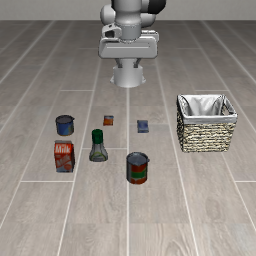

In [7]:
from libero.libero.envs import OffScreenRenderEnv
from IPython.display import display
from PIL import Image
bddl_visualise = 'tmp/pddl_files/pick_up_the_alphabet_soup_and_place_it_in_the_basket.bddl'

with open(bddl_visualise, "r") as f:
    content = f.read()
print(content)

env_args = {
    "bddl_file_name": bddl_visualise,
    "camera_heights": 256,
    "camera_widths": 256
}

env = OffScreenRenderEnv(**env_args)
obs = env.reset()
display(Image.fromarray(obs["agentview_image"][::-1]))